# CNN financial sentiment

Base model: `yassiracharki/Pre-trained_model_Binary_CNN_NLP_Amazon_Reviews`

This notebook uses the pretrained Amazon CNN checkpoint as the base model. Because the repo does not ship a tokenizer file, the tokenizer is reconstructed from the source Amazon dataset referenced by the model card, then the original binary head is replaced with a 3-class head and trained in two stages.

In [8]:
from pathlib import Path
import sys

import pandas as pd
from datasets import load_dataset
from tensorflow import keras
from IPython.display import display

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from utils.text_utils import (
    download_hf_file,
    evaluate_keras_model,
    keras_text_splits,
    load_data,
    metrics_table,
    plot_history,
    replace_keras_classifier,
    set_seed,
    summarize_splits,
    train_keras_transfer_model,
)

set_seed(42)

In [9]:
BASE_REPO = "yassiracharki/Pre-trained_model_Binary_CNN_NLP_Amazon_Reviews"
BASE_MODEL_FILE = "Binary_Classification_86_Amazon_Reviews_CNN.h5"
TOKENIZER_SOURCE_DATASET = "yassiracharki/Amazon_Reviews_Binary_for_Sentiment_Analysis"
TOKENIZER_TEXT_COLUMN = "review_text"

df = load_data()
display(summarize_splits(df))

,rows,mean_words,negative,neutral,positive
split,,,,,
test,23566,17.30,5817,7306,10443
train,77589,18.01,18856,25403,33330
validation,23567,17.36,5722,7261,10584


In [10]:
base_model_path = download_hf_file(BASE_REPO, BASE_MODEL_FILE)
base_model = keras.models.load_model(base_model_path, compile=False)
base_model.summary()

/home/automac/Documents/Estudios/Semestre3/ProyectoDeGrado/.venv/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/home/automac/Documents/Estudios/Semestre3/ProyectoDeGrado/.venv/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 220, 300)       │    52,289,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 220, 32)        │        38,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 110, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 110, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 110, 64)        │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 55, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 55, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 55, 64)         │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 27, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 27, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1728)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       442,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,795,717 (201.40 MB)

 Trainable params: 52,795,717 (201.40 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
max_length = int(base_model.input_shape[1])
embedding_layer = next(layer for layer in base_model.layers if hasattr(layer, "input_dim"))
vocab_size = int(embedding_layer.input_dim)

tokenizer_source = load_dataset(TOKENIZER_SOURCE_DATASET, split="train")
tokenizer_source = tokenizer_source.select(range(min(100000, len(tokenizer_source))))

tokenizer = keras.preprocessing.text.Tokenizer(num_words=vocab_size)
tokenizer.fit_on_texts(tokenizer_source[TOKENIZER_TEXT_COLUMN])

splits = keras_text_splits(df, tokenizer=tokenizer, max_length=max_length)

x_train, y_train = splits["train"]
x_valid, y_valid = splits["validation"]
x_test, y_test = splits["test"]

In [12]:
transfer_model = replace_keras_classifier(base_model, num_classes=3)
transfer_model.summary()

Model: "functional_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ transfer_input (InputLayer)     │ (None, 220)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 220, 300)       │    52,289,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 220, 32)        │        38,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 110, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 110, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 110, 64)        │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 55, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 55, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 55, 64)         │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 27, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 27, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1728)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       442,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transfer_head (Dense)           │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,796,231 (201.40 MB)

 Trainable params: 52,796,231 (201.40 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/4
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.4084 - loss: 1.4770 - val_accuracy: 0.4264 - val_loss: 1.0954
Epoch 2/4
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.4219 - loss: 1.1253 - val_accuracy: 0.4485 - val_loss: 1.0954
Epoch 3/4
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.4213 - loss: 1.1236 - val_accuracy: 0.4488 - val_loss: 1.0733
Epoch 4/4
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.4208 - loss: 1.1181 - val_accuracy: 0.4469 - val_loss: 1.0929
Epoch 1/6
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.4292 - loss: 1.0790 - val_accuracy: 0.4498 - val_loss: 1.0662
Epoch 2/6
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.4283 - loss: 1.0769 - val_accuracy: 0.4493 - val_loss: 1.0671
Epoch 3/6
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.4290 - loss: 1.0764 - val_accuracy: 0.4395 - val_loss: 1.0703
Epoch 4/6
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.4294 - loss: 1.075

,epoch,train_loss,validation_loss,validation_accuracy
0,1,1.477046,1.095430,0.426401
1,2,1.125273,1.095360,0.448509
2,3,1.123572,1.073293,0.448763
3,4,1.118144,1.092946,0.446896
4,5,1.079003,1.066202,0.449824
5,6,1.076938,1.067106,0.449315
6,7,1.076381,1.070288,0.439513
7,8,1.075288,1.065712,0.450418
8,9,1.074370,1.069557,0.448254
9,10,1.074772,1.066688,0.449866


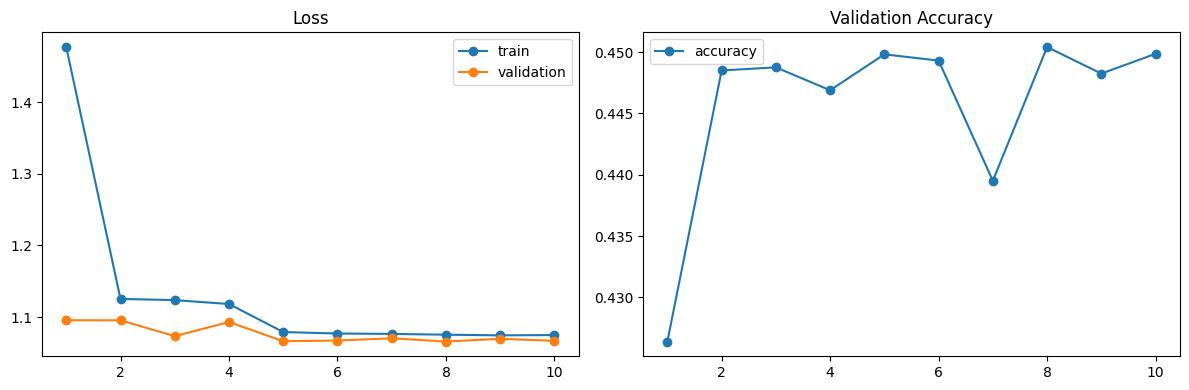

In [13]:
history = train_keras_transfer_model(
    transfer_model,
    train_data=(x_train, y_train),
    validation_data=(x_valid, y_valid),
    head_epochs=4,
    full_epochs=6,
    head_learning_rate=1e-3,
    full_learning_rate=1e-4,
    batch_size=64,
    unfreeze_layers_from_end=4,
)

plot_history(history)
history

In [14]:
test_texts = df[df["split"] == "test"]["text"].tolist()
results = evaluate_keras_model(transfer_model, x_test, y_test, texts=test_texts)
display(metrics_table(results))
display(results["report"])
display(results["confusion_matrix"])
results["predictions"].head()

,metric,value
0,accuracy,0.444624
1,macro_precision,0.779513
2,macro_recall,0.335018
3,macro_f1,0.208449
4,weighted_f1,0.275613


,precision,recall,f1-score,support
negative,1.000000,0.000688,0.001374,5817.000000
neutral,0.894737,0.004654,0.009259,7306.000000
positive,0.443802,0.999713,0.614714,10443.000000
accuracy,0.444624,0.444624,0.444624,0.444624
macro avg,0.779513,0.335018,0.208449,23566.000000
weighted avg,0.720893,0.444624,0.275613,23566.000000


,negative,neutral,positive
negative,4,1,5812
neutral,0,34,7272
positive,0,3,10440


,text,label,prediction
0,hqge ltnc hbrm enzc eeenf halb azfl maxd mmex ...,positive,positive
1,econx november nonfarm private payrolls k vs k...,positive,positive
2,regulatory news the nomination committee of cy...,neutral,positive
3,amazon labor union is now seeking to represent...,positive,positive
4,greene king s third quarter sales boosted by f...,positive,positive
